# 데이터 점검 — 분포·이상치·결측값

학습을 돌리기 전에 데이터에 무슨 문제가 있는지 한눈에 보는 노트북이다. 순서대로 본다.

1. **원본 사진**: 몇 장인지, 해상도가 충분한지
2. **라벨 JSON**: 항목별 결측(`None`), 등급 분포, 측정값 이상치
3. **추출 결과(`index.csv`)**: 실패 건수, 얼굴 크기, 피부 픽셀 이상치
4. **사람 메타**: 나이·성별 분포

In [22]:
import csv
import importlib
import json
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

import face_regions

importlib.reload(face_regions)  # face_regions.py 수정사항을 커널 재시작 없이 반영
from face_regions import DATA_DIR

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

DATA_OUT = Path.cwd().parent / "data"
INDEX_PATH = DATA_OUT / "index.csv"
DEVICES = {"2. 스마트패드": "스마트패드", "3. 스마트폰": "스마트폰"}  # 디지털카메라는 색 차이가 커서 제외

## 1. 원본 사진

해상도는 헤더만 읽어서 빠르게 확인한다 (사진을 다 디코딩하지 않는다).

In [23]:
images = sorted(p for d in DEVICES for p in DATA_DIR.glob(f"*/01.원천데이터/{d}/*/*.jpg"))
print(f"사진 {len(images):,}장, 사람 {len({p.parts[-2] for p in images}):,}명")
print("기기별:", dict(Counter(p.parts[-3] for p in images)))
print("각도별:", dict(Counter(p.stem.split('_')[2] for p in images)))
print("split별:", dict(Counter(p.parts[-5] for p in images)))

sizes = {}
for path in images:
    with open(path, "rb") as f:  # JPEG 헤더에서 크기만 읽는다
        head = f.read(2)
        while True:
            block = f.read(2)
            if not block or block[0] != 0xFF:
                break
            if 0xC0 <= block[1] <= 0xCF and block[1] not in (0xC4, 0xC8, 0xCC):
                f.read(3)
                h, w = int.from_bytes(f.read(2), "big"), int.from_bytes(f.read(2), "big")
                sizes[path] = (w, h)
                break
            f.read(int.from_bytes(f.read(2), "big") - 2)

pixels = np.array([w * h for w, h in sizes.values()])
print(f"\n해상도 분포 (백만 픽셀): 최소 {pixels.min() / 1e6:.2f}, 중앙 {np.median(pixels) / 1e6:.2f}, 최대 {pixels.max() / 1e6:.2f}")
small = {p: s for p, s in sizes.items() if s[0] * s[1] < 1e6}
print(f"1백만 픽셀 미만(저해상도): {len(small)}장, 사람 {len({p.parts[-2] for p in small}):,}명")
for path, size in list(small.items())[:5]:
    print(f"   {path.parts[-2]} {path.parts[-3]} {path.name}: {size[0]}x{size[1]}")

사진 5,790장, 사람 965명
기기별: {'2. 스마트패드': 2895, '3. 스마트폰': 2895}
각도별: {'F': 1930, 'L': 1930, 'R': 1930}
split별: {'Training': 5148, 'Validation': 642}

해상도 분포 (백만 픽셀): 최소 0.17, 중앙 7.99, 최대 31.96
1백만 픽셀 미만(저해상도): 57장, 사람 19명
   0003 3. 스마트폰 0003_03_F.jpg: 360x480
   0003 3. 스마트폰 0003_03_L.jpg: 360x480
   0003 3. 스마트폰 0003_03_R.jpg: 360x480
   0006 3. 스마트폰 0006_03_F.jpg: 600x800
   0006 3. 스마트폰 0006_03_L.jpg: 600x800


## 2. 라벨 JSON

정답은 사람마다 한 세트다(각도·기기가 달라도 값이 같다). 그래서 사람마다 스마트폰 정면 파일만 읽는다.

- `annotations`: 사람이 매긴 등급
- `equipment`: 기기로 잰 측정값

In [24]:
PARTS = {0: "얼굴 전체", 1: "이마", 2: "미간", 3: "눈가 좌", 4: "눈가 우", 5: "볼 좌", 6: "볼 우", 7: "입술", 8: "턱"}

# 항목 → {사람번호: 값}. 사람 번호를 같이 들고 있어야 이상치가 누구인지 찾을 수 있다.
grades = defaultdict(dict)
equipment = defaultdict(dict)
missing = Counter()
subjects = {}
for split in ["Training", "Validation"]:
    for subject_dir in sorted((DATA_DIR / split / "02.라벨링데이터" / "3. 스마트폰").iterdir()):
        if not subject_dir.is_dir():
            continue
        subject = subject_dir.name
        for part in PARTS:
            paths = sorted(subject_dir.glob(f"*_F_{part:02d}.json"))
            if not paths:
                missing[f"{PARTS[part]} 파일 없음"] += 1
                continue
            label = json.loads(paths[0].read_text())
            subjects[subject] = dict(label["info"], split=split)
            for key, value in label["annotations"].items():
                if isinstance(value, int):
                    grades[key][subject] = value
                else:
                    missing[f"{key}=None"] += 1
            for key, value in (label["equipment"] or {}).items():
                if value is None:
                    missing[f"{key}=None"] += 1
                else:
                    equipment[key][subject] = value

print(f"사람 {len(subjects):,}명")
print("\n결측:", dict(missing) or "없음")
print(f"\n{'등급 항목':26s} {'인원':>6s}  분포")
for key, values in grades.items():
    counts = Counter(values.values())
    print(f"  {key:24s} {len(values):6,d}  " + " ".join(f"{g}:{counts[g]}" for g in sorted(counts)))

사람 965명

결측: {'acne=None': 965}

등급 항목                          인원  분포
  forehead_pigmentation       965  0:196 1:494 2:184 3:80 4:7 5:4
  forehead_wrinkle            965  0:39 1:354 2:232 3:160 4:76 5:59 6:45
  glabellus_wrinkle           965  0:198 1:418 2:118 3:102 4:35 5:62 6:32
  l_perocular_wrinkle         965  0:68 1:321 2:143 3:144 4:89 5:99 6:101
  r_perocular_wrinkle         965  0:68 1:322 2:140 3:140 4:100 5:97 6:98
  l_cheek_pore                965  0:26 1:173 2:583 3:122 4:51 5:10
  l_cheek_pigmentation        965  0:29 1:278 2:256 3:262 4:102 5:38
  r_cheek_pore                965  0:26 1:165 2:590 3:121 4:53 5:10
  r_cheek_pigmentation        965  0:24 1:263 2:253 3:271 4:105 5:49
  lip_dryness                 965  0:21 1:158 2:587 3:177 4:22
  chin_sagging                965  0:440 1:192 2:126 3:118 4:52 5:36 6:1


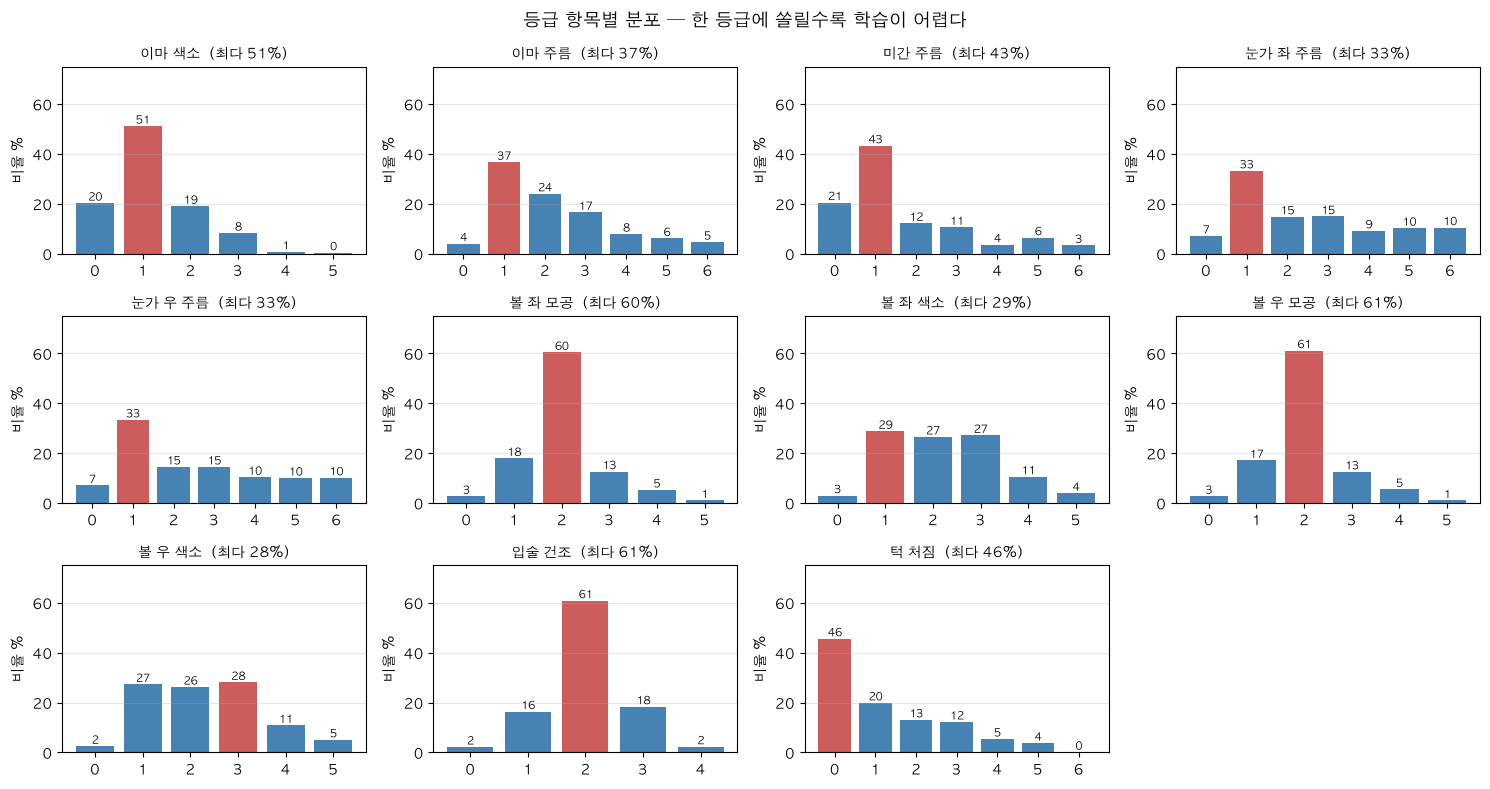

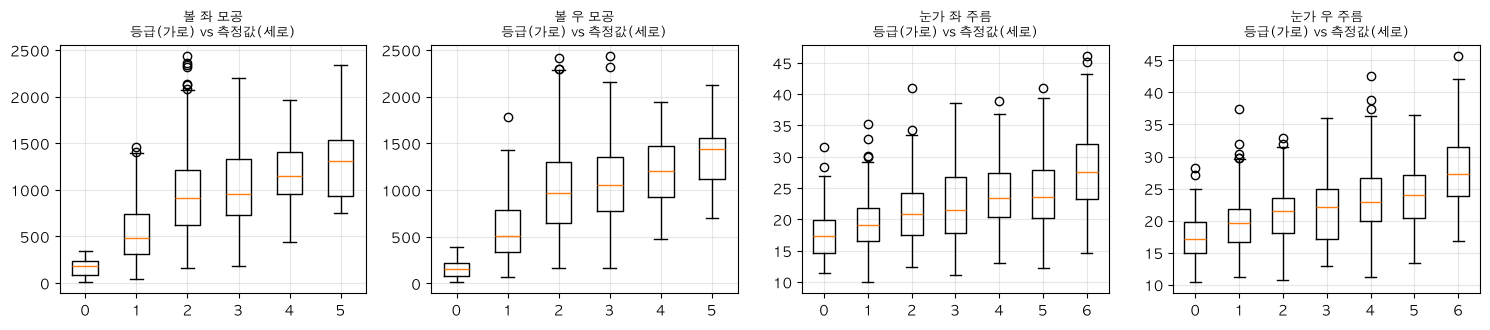

In [25]:
KOREAN = {"forehead_pigmentation": "이마 색소", "forehead_wrinkle": "이마 주름", "glabellus_wrinkle": "미간 주름",
          "l_perocular_wrinkle": "눈가 좌 주름", "r_perocular_wrinkle": "눈가 우 주름",
          "l_cheek_pore": "볼 좌 모공", "r_cheek_pore": "볼 우 모공",
          "l_cheek_pigmentation": "볼 좌 색소", "r_cheek_pigmentation": "볼 우 색소",
          "lip_dryness": "입술 건조", "chin_sagging": "턱 처짐"}

items = list(grades)
fig, axes = plt.subplots(3, 4, figsize=(15, 8))
for ax, key in zip(axes.ravel(), items):
    counts = Counter(grades[key].values())
    levels = sorted(counts)
    share = [counts[g] / len(grades[key]) * 100 for g in levels]
    top = max(share)
    # 가장 많은 등급을 붉게 (한쪽으로 쏠렸는지 바로 보인다)
    colors = ["indianred" if s == top else "steelblue" for s in share]
    ax.bar(levels, share, color=colors)
    for g, s in zip(levels, share):
        ax.text(g, s + 1, f"{s:.0f}", ha="center", fontsize=8)
    ax.set_title(f"{KOREAN.get(key, key)}  (최다 {top:.0f}%)", fontsize=10)
    ax.set_xticks(levels)
    ax.set_ylim(0, 75)
    ax.set_ylabel("비율 %")
    ax.grid(alpha=.3, axis="y")
for ax in axes.ravel()[len(items):]:
    ax.axis("off")
fig.suptitle("등급 항목별 분포 — 한 등급에 쏠릴수록 학습이 어렵다", fontsize=13)
plt.tight_layout()
plt.show()

# 측정값이 있는 항목은 등급과 실제로 맞는지 확인 (등급이 오르면 측정값도 올라야 정상)
PAIRS = [("l_cheek_pore", "l_cheek_pore"), ("r_cheek_pore", "r_cheek_pore"),
         ("l_perocular_wrinkle", "l_perocular_wrinkle_Ra"), ("r_perocular_wrinkle", "r_perocular_wrinkle_Ra")]
fig, axes = plt.subplots(1, len(PAIRS), figsize=(15, 3.4))
for ax, (grade_key, value_key) in zip(axes, PAIRS):
    common = sorted(set(grades[grade_key]) & set(equipment[value_key]))
    g = np.array([grades[grade_key][s] for s in common])
    v = np.array([equipment[value_key][s] for s in common], dtype=float)
    ax.boxplot([v[g == level] for level in sorted(set(g))], tick_labels=sorted(set(g)))
    ax.set_title(f"{KOREAN.get(grade_key, grade_key)}\n등급(가로) vs 측정값(세로)", fontsize=9)
    ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

In [34]:
# 관심 있는 측정값의 분포와 이상치. 이상치는 사람 번호까지 뽑아 사진을 직접 확인할 수 있게 한다.
WATCH = ["l_cheek_pore", "r_cheek_pore", "l_perocular_wrinkle_Ra", "r_perocular_wrinkle_Ra",
         "pigmentation_count", "forehead_moisture", "l_cheek_moisture"]


def outliers(key, factor=1.5):
    """IQR 기준 이상치 [(사람번호, 값, '낮음'/'높음'), ...]. 경계에서 먼 순서로 정렬."""
    items = equipment[key]
    values = np.array(list(items.values()), dtype=float)
    q1, q3 = np.percentile(values, [25, 75])
    low, high = q1 - factor * (q3 - q1), q3 + factor * (q3 - q1)
    found = [(s, v, "낮음" if v < low else "높음") for s, v in items.items() if v < low or v > high]
    return sorted(found, key=lambda x: min(abs(x[1] - low), abs(x[1] - high)), reverse=True)


print(f"{'측정 항목':26s} {'개수':>6s} {'최소':>8s} {'중앙':>8s} {'최대':>8s} {'IQR이상값':>7s}")
outlier_subjects = {}
for key in WATCH:
    values = np.array(list(equipment.get(key, {}).values()), dtype=float)
    if not len(values):
        continue
    outlier_subjects[key] = outliers(key)
    print(f"  {key:24s} {len(values):6,d} {values.min():8.1f} {np.median(values):8.1f} {values.max():8.1f} "
          f"{len(outlier_subjects[key]):5d}개")

# print("\n이상치에 해당하는 사람 (face_regions.ipynb의 SUBJECT에 넣어 확인)")
# for key, found in outlier_subjects.items():
#     if not found:
#         continue
#     print(f"\n  {key}  (중앙값 {np.median(list(equipment[key].values())):.1f})")
#     for subject, value, side in found:
#         info = subjects[subject]
#         print(f"     {subject}  {value:8.1f} ({side})  {info['gender']} {info['age']}세  {info['split']}")

측정 항목                          개수       최소       중앙       최대  IQR이상값
  l_cheek_pore                965     10.0    845.0   2438.0     7개
  r_cheek_pore                965     15.0    901.0   2436.0     5개
  l_perocular_wrinkle_Ra      965     10.0     21.0     46.1    16개
  r_perocular_wrinkle_Ra      965     10.4     21.1     45.7    19개
  pigmentation_count          965     16.0    157.0    341.0     0개
  forehead_moisture           965     24.7     60.7     94.3    11개
  l_cheek_moisture            965     22.3     62.7     98.7     8개


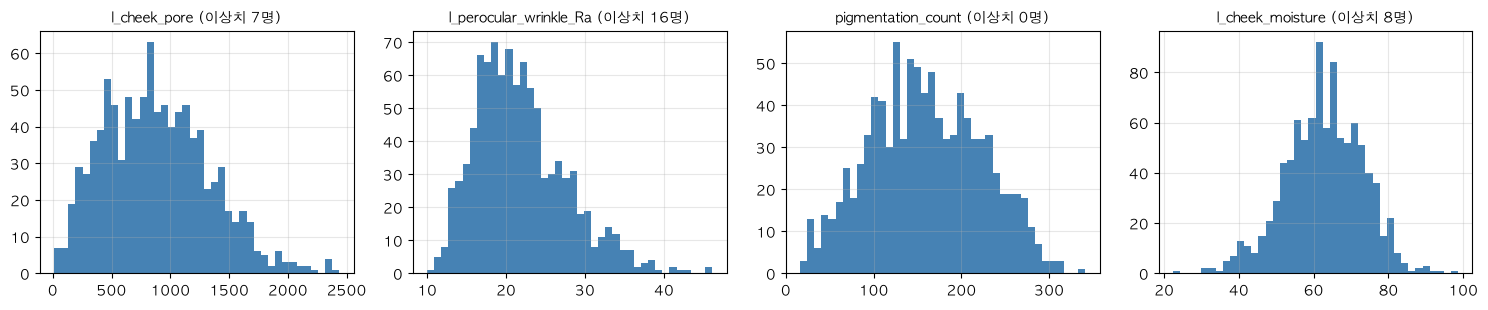

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, key in zip(axes, ["l_cheek_pore", "l_perocular_wrinkle_Ra", "pigmentation_count", "l_cheek_moisture"]):
    values = np.array(list(equipment[key].values()), dtype=float)
    ax.hist(values, bins=40, color="steelblue")
    ax.set_title(f"{key} (이상치 {len(outlier_subjects.get(key, []))}명)", fontsize=10)
    ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

## 3. 추출 결과 (`data/index.csv`)

`extract_regions.ipynb`를 돌린 뒤에 확인한다.

- `status`: `ok` / `hidden_view`(각도상 가려짐, 정상) / `no_face`(랜드마크 실패) / `empty`(남은 피부 없음)
- `face_h`가 작으면 저해상도라 확대가 심해진다 → 질감이 뭉개진다
- `skin_px`가 유독 작으면 머리카락·손 등에 가려졌을 가능성

In [28]:
if not INDEX_PATH.exists():
    print(f"{INDEX_PATH} 가 없다. extract_regions.ipynb 를 먼저 실행할 것.")
else:
    rows = list(csv.DictReader(open(INDEX_PATH, newline="")))
    ok = [r for r in rows if r["status"] == "ok"]
    print(f"행 {len(rows):,} | 사진 {len({(r['stem'], r['device']) for r in rows}):,} | 사람 {len({r['subject'] for r in rows}):,}")
    print("status:", dict(Counter(r["status"] for r in rows)))
    print("실패:", [(r["subject"], r["device"], r["view"], r["region"], r["status"]) for r in rows
                 if r["status"] in ("no_face", "empty")][:10] or "없음")

    face_h = {(r["subject"], r["device"], r["view"]): float(r["face_h"]) for r in ok}
    values = np.array(list(face_h.values()))
    print(f"\n얼굴 세로 길이(px): 최소 {values.min():.0f} | 1% {np.percentile(values, 1):.0f} | "
          f"중앙 {np.median(values):.0f} | 최대 {values.max():.0f}")
    low = sorted(k for k, v in face_h.items() if v < 800)
    print(f"800px 미만(확대가 심해지는 사진): {len(low)}장, 사람 {len({k[0] for k in low})}명")
    print("  예:", low[:5])

    print(f"\n{'부위':10s} {'개수':>6s} {'피부픽셀 중앙':>12s} {'하위 1%':>10s} {'최소':>8s}")
    for region in face_regions.REGION_NAMES:
        skin = np.array([int(r["skin_px"]) for r in ok if r["region"] == region])
        print(f"  {region:8s} {len(skin):6,d} {np.median(skin):12,.0f} {np.percentile(skin, 1):10,.0f} {skin.min():8,d}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
    axes[0].hist(values, bins=50, color="steelblue")
    axes[0].axvline(800, color="red", ls="--"); axes[0].set_title("얼굴 세로 길이(px)"); axes[0].grid(alpha=.3)
    for region in ["l_cheek", "forehead", "l_eye"]:
        axes[1].hist([int(r["skin_px"]) for r in ok if r["region"] == region], bins=50, alpha=.5, label=region)
    axes[1].set_title("부위별 피부 픽셀 수"); axes[1].legend(); axes[1].grid(alpha=.3)
    axes[2].scatter([face_h[(r["subject"], r["device"], r["view"])] for r in ok if r["region"] == "l_cheek"],
                    [int(r["skin_px"]) for r in ok if r["region"] == "l_cheek"], s=4, alpha=.3)
    axes[2].set_title("얼굴 크기 vs 볼 피부 픽셀"); axes[2].set_xlabel("face_h"); axes[2].grid(alpha=.3)
    plt.tight_layout()
    plt.show()

/Users/USER/Desktop/소마/face_analysis_AI/data/index.csv 가 없다. extract_regions.ipynb 를 먼저 실행할 것.


## 4. 사람 메타 (나이·성별)

특정 나이대나 성별에 쏠려 있으면 모델이 그 집단에만 맞춰질 수 있다.

성별: {'F': 483, 'M': 482}
split: {'Training': 858, 'Validation': 107}
나이: 최소 13, 중앙 41, 최대 69
피부타입: {0: 234, 3: 139, 1: 279, 4: 142, 5: 168, 2: 3}
민감성: {0: 677, 1: 288}


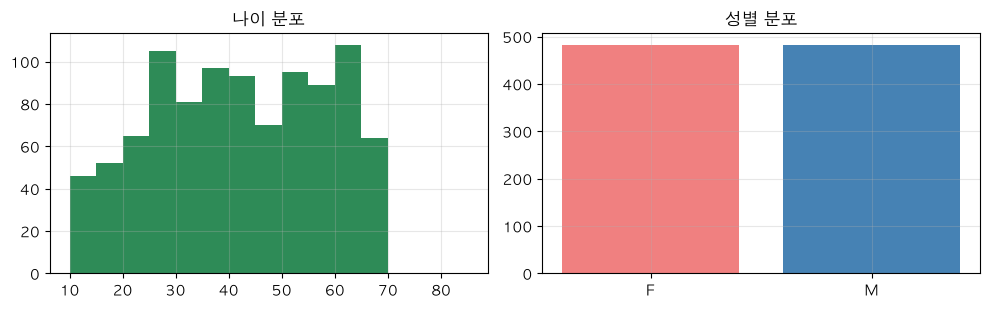

In [29]:
ages = np.array([s["age"] for s in subjects.values()])
print("성별:", dict(Counter(s["gender"] for s in subjects.values())))
print("split:", dict(Counter(s["split"] for s in subjects.values())))
print(f"나이: 최소 {ages.min()}, 중앙 {np.median(ages):.0f}, 최대 {ages.max()}")
print("피부타입:", dict(Counter(s.get("skin_type") for s in subjects.values())))
print("민감성:", dict(Counter(s.get("sensitive") for s in subjects.values())))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].hist(ages, bins=range(10, 90, 5), color="seagreen")
axes[0].set_title("나이 분포"); axes[0].grid(alpha=.3)
counts = Counter(s["gender"] for s in subjects.values())
axes[1].bar(list(counts), list(counts.values()), color=["lightcoral", "steelblue"])
axes[1].set_title("성별 분포"); axes[1].grid(alpha=.3)
plt.tight_layout()
plt.show()